# Final Project: Retinal Fundus Image Classification Neural Network

In [13]:
import pandas as pd

### Data Loading

In [14]:
import kagglehub
import os

# Download full dataset
dataset_path = kagglehub.dataset_download("harsha1289/combined-dr-dataset-aptosidridmessidoreyepacs")

print("Dataset downloaded to:", dataset_path)

# Inspect folder
for root, dirs, files in os.walk(dataset_path):
    print(root, "->", files[:5])
    break

Dataset downloaded to: /Users/joshuademontigny/.cache/kagglehub/datasets/harsha1289/combined-dr-dataset-aptosidridmessidoreyepacs/versions/1
/Users/joshuademontigny/.cache/kagglehub/datasets/harsha1289/combined-dr-dataset-aptosidridmessidoreyepacs/versions/1 -> ['labels.csv', 'val.csv', 'test.csv', 'train.csv']


In [15]:
import pandas as pd
import os

base_path = "/Users/joshuademontigny/.cache/kagglehub/datasets/harsha1289/combined-dr-dataset-aptosidridmessidoreyepacs/versions/1"

df = pd.read_csv(os.path.join(base_path, "labels.csv"))

df["full_path"] = df["image_path"].apply(lambda x: os.path.join(base_path, x))

df.head()

,image_path,id_code,diagnosis,split,full_path
0,train/3/3748_right-600-SF.jpg,3748_right-600-SF,3,train,/Users/joshuademontigny/.cache/kagglehub/datas...
1,train/1/5994_left-600-HFF.jpg,5994_left-600-HFF,1,train,/Users/joshuademontigny/.cache/kagglehub/datas...
2,train/4/3796af4d987a-GF-600-HFF.jpg,3796af4d987a-GF-600-HFF,4,train,/Users/joshuademontigny/.cache/kagglehub/datas...
3,test/0/37617_right-600.jpg,37617_right-600,0,test,/Users/joshuademontigny/.cache/kagglehub/datas...
4,test/0/6822_right-600.jpg,6822_right-600,0,test,/Users/joshuademontigny/.cache/kagglehub/datas...


### Data Validity Checks

In [16]:
df.groupby('split')['diagnosis'].value_counts(normalize=True).unstack()

diagnosis,0,1,2,3,4
split,,,,,
test,0.461716,0.121704,0.243178,0.086010,0.087392
train,0.238095,0.166667,0.214286,0.190476,0.190476
val,0.477422,0.151874,0.197628,0.074979,0.098096


In [17]:
from PIL import Image

df['image_shape'] = df['full_path'].apply(lambda x: Image.open(x).size)
df['image_shape'].value_counts()

image_shape
(600, 600)    38034
Name: count, dtype: int64

In [18]:
def is_valid_image(path):
    try:
        Image.open(path).verify()
        return True
    except:
        return False

df['valid'] = df['full_path'].apply(is_valid_image)
df['valid'].value_counts()

valid
True    38034
Name: count, dtype: int64

### Exploratory Data Analysis

In [19]:
# Check how many files exist
print(df["full_path"].apply(os.path.exists).mean())  # should be 1.0

# Check class balance
print(df["diagnosis"].value_counts().sort_index())

1.0
diagnosis
0    12996
1     5825
2     8262
3     5373
4     5578
Name: count, dtype: int64


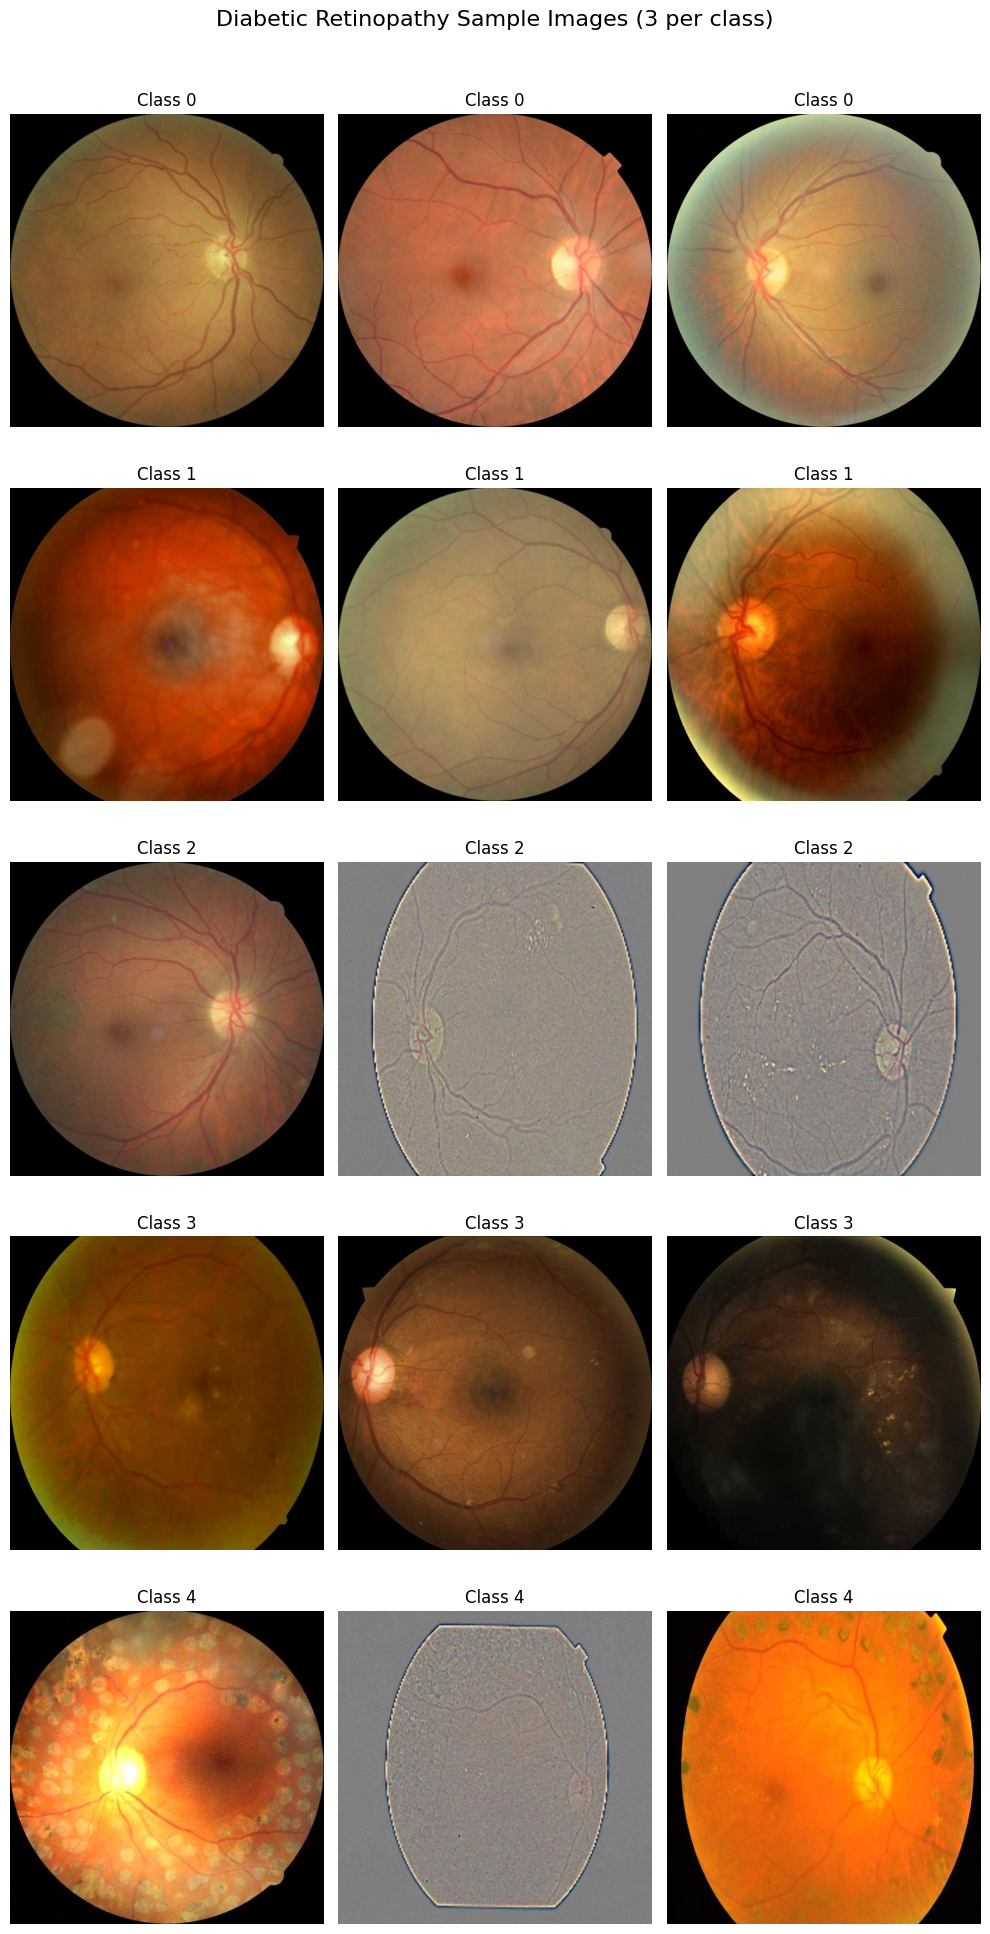

In [20]:
import matplotlib.pyplot as plt

# Prepare figure
fig, axes = plt.subplots(5, 3, figsize=(10, 20))
fig.suptitle("Diabetic Retinopathy Sample Images (3 per class)", fontsize=16)

# Loop through each class (0–4)
for cls in range(5):
    # Get all images of this class
    cls_df = df[df["diagnosis"] == cls]
    
    # Take 2 random samples
    samples = cls_df.sample(3, random_state=42)
    
    for i, (_, row) in enumerate(samples.iterrows()):
        ax = axes[cls, i]
        img = plt.imread(row["full_path"])
        ax.imshow(img)
        ax.set_title(f"Class {cls}")
        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])  
plt.show()

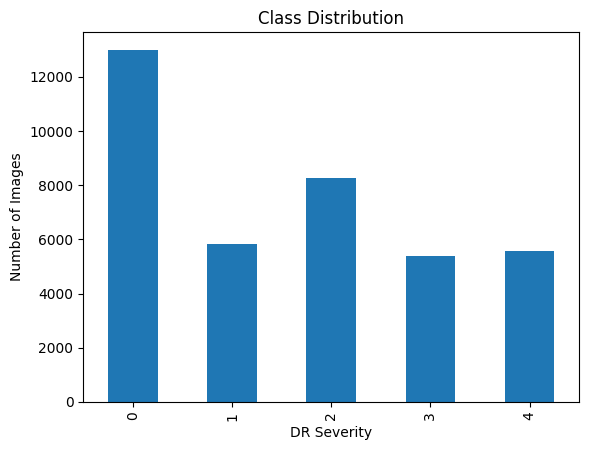

In [21]:
import matplotlib.pyplot as plt

df['diagnosis'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('DR Severity')
plt.ylabel('Number of Images')
plt.title('Class Distribution')
plt.show()

### Baseline CNN Model

In [36]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 3


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [37]:
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [38]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []


for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df["diagnosis"])):
    
    print(f"\n===== Fold {fold+1} =====")
    
    train_fold = train_df.iloc[train_idx]
    val_fold   = train_df.iloc[val_idx]
    train_fold["diagnosis"] = train_fold["diagnosis"].astype(str)
    val_fold["diagnosis"]   = val_fold["diagnosis"].astype(str)

    train_gen = train_datagen.flow_from_dataframe(
        train_fold,
        x_col="full_path",
        y_col="diagnosis",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE
    )

    val_gen = val_datagen.flow_from_dataframe(
        val_fold,
        x_col="full_path",
        y_col="diagnosis",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE
    )

    model = build_model()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(val_gen, verbose=0)

    print(f"Fold {fold+1} Accuracy: {val_acc:.4f}")

    fold_results.append(val_acc)



===== Fold 1 =====
Found 16800 validated image filenames belonging to 5 classes.
Found 4200 validated image filenames belonging to 5 classes.


/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_fold["diagnosis"] = train_fold["diagnosis"].astype(str)
/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_fold["diagnosis"]   = val_fold["diagnosis"].astype(str)
/Users/joshuademontigny/miniconda3/envs/dl_course/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: User

Epoch 1/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 370s 702ms/step - accuracy: 0.2680 - loss: 1.5982 - val_accuracy: 0.2943 - val_loss: 1.5932
Epoch 2/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 373s 709ms/step - accuracy: 0.3130 - loss: 1.5316 - val_accuracy: 0.3431 - val_loss: 1.6663
Epoch 3/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 371s 707ms/step - accuracy: 0.3515 - loss: 1.4686 - val_accuracy: 0.3295 - val_loss: 1.9414
Fold 1 Accuracy: 0.3295

===== Fold 2 =====
Found 16800 validated image filenames belonging to 5 classes.
Found 4200 validated image filenames belonging to 5 classes.


/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_fold["diagnosis"] = train_fold["diagnosis"].astype(str)
/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_fold["diagnosis"]   = val_fold["diagnosis"].astype(str)
/Users/joshuademontigny/miniconda3/envs/dl_course/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: User

Epoch 1/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 366s 697ms/step - accuracy: 0.2809 - loss: 1.5878 - val_accuracy: 0.3071 - val_loss: 1.5267
Epoch 2/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 366s 697ms/step - accuracy: 0.3313 - loss: 1.5211 - val_accuracy: 0.3645 - val_loss: 1.4677
Epoch 3/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 368s 700ms/step - accuracy: 0.3603 - loss: 1.4750 - val_accuracy: 0.3700 - val_loss: 1.4492
Fold 2 Accuracy: 0.3700

===== Fold 3 =====
Found 16800 validated image filenames belonging to 5 classes.
Found 4200 validated image filenames belonging to 5 classes.


...

Epoch 1/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 375s 712ms/step - accuracy: 0.2976 - loss: 1.5510 - val_accuracy: 0.3395 - val_loss: 1.4831
Epoch 2/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 373s 711ms/step - accuracy: 0.3321 - loss: 1.5010 - val_accuracy: 0.3417 - val_loss: 1.4820
Epoch 3/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 374s 712ms/step - accuracy: 0.3662 - loss: 1.4603 - val_accuracy: 0.3812 - val_loss: 1.3995
Fold 3 Accuracy: 0.3812

===== Fold 4 =====
Found 16800 validated image filenames belonging to 5 classes.
Found 4200 validated image filenames belonging to 5 classes.


/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_fold["diagnosis"] = train_fold["diagnosis"].astype(str)
/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_fold["diagnosis"]   = val_fold["diagnosis"].astype(str)
/Users/joshuademontigny/miniconda3/envs/dl_course/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: User

Epoch 1/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 383s 729ms/step - accuracy: 0.3015 - loss: 1.5557 - val_accuracy: 0.3088 - val_loss: 1.5436
Epoch 2/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 382s 727ms/step - accuracy: 0.3402 - loss: 1.4942 - val_accuracy: 0.3586 - val_loss: 1.4604
Epoch 3/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 483s 921ms/step - accuracy: 0.3549 - loss: 1.4616 - val_accuracy: 0.3860 - val_loss: 1.4151
Fold 4 Accuracy: 0.3860

===== Fold 5 =====
Found 16800 validated image filenames belonging to 5 classes.
Found 4200 validated image filenames belonging to 5 classes.


/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_fold["diagnosis"] = train_fold["diagnosis"].astype(str)
/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_28962/4048092452.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_fold["diagnosis"]   = val_fold["diagnosis"].astype(str)
/Users/joshuademontigny/miniconda3/envs/dl_course/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: User

Epoch 1/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 389s 740ms/step - accuracy: 0.2841 - loss: 1.5713 - val_accuracy: 0.3110 - val_loss: 1.5250
Epoch 2/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 1562s 3s/step - accuracy: 0.3393 - loss: 1.4966 - val_accuracy: 0.3712 - val_loss: 1.4388
Epoch 3/3
525/525 ━━━━━━━━━━━━━━━━━━━━ 379s 721ms/step - accuracy: 0.3629 - loss: 1.4544 - val_accuracy: 0.3776 - val_loss: 1.4500
Fold 5 Accuracy: 0.3776


In [39]:
print("\n===== K-FOLD RESULTS =====")
print("Accuracies:", fold_results)
print("Mean Accuracy:", np.mean(fold_results))
print("Std Dev:", np.std(fold_results))


===== K-FOLD RESULTS =====
Accuracies: [0.32952380180358887, 0.3700000047683716, 0.3811904788017273, 0.3859523832798004, 0.37761905789375305]
Mean Accuracy: 0.36885714530944824
Std Dev: 0.02034476555540772


In [41]:
train_df["diagnosis"] = train_df["diagnosis"].astype(str)

final_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="full_path",
    y_col="diagnosis",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE
)

final_model = build_model()

final_model.fit(final_gen, epochs=EPOCHS)

Found 21000 validated image filenames belonging to 5 classes.


/Users/joshuademontigny/miniconda3/envs/dl_course/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
657/657 ━━━━━━━━━━━━━━━━━━━━ 399s 606ms/step - accuracy: 0.3198 - loss: 1.5331
Epoch 2/3
657/657 ━━━━━━━━━━━━━━━━━━━━ 466s 708ms/step - accuracy: 0.3614 - loss: 1.4612
Epoch 3/3
657/657 ━━━━━━━━━━━━━━━━━━━━ 444s 676ms/step - accuracy: 0.3791 - loss: 1.4249


TypeError: If class_mode="categorical", y_col="diagnosis" column values must be type string, list or tuple.

In [44]:
test_df["diagnosis"] = test_df["diagnosis"].astype(str)


test_gen = val_datagen.flow_from_dataframe(
    test_df,
    x_col="full_path",
    y_col="diagnosis",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loss, test_acc = final_model.evaluate(test_gen)

print("\n===== FINAL TEST PERFORMANCE =====")
print("Test Accuracy:", round(test_acc,3))

Found 8685 validated image filenames belonging to 5 classes.
272/272 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.5060 - loss: 1.3565

===== FINAL TEST PERFORMANCE =====
Test Accuracy: 0.506
